# Task 3 — Notebook 03: Maps, time series, state×crop table, run bundle

**Inputs:** `smap_anomaly_{event_id}.parquet` for each `event_windows` entry in `configs/task3_soil_moisture.yaml`, CDL spatial metadata, Corn Belt state boundaries.

**Figures (per event):** four z-maps at spread ISO weeks in the window, mean z time series, and a duration map (wet: fraction of weeks with z above `duration_z`; dry: fraction below `duration_z`).

**Tables:** `artifacts/tables/task3/task3__{event_id}__anomaly_stats_by_state_crop__*.csv`

**Run log:** `artifacts/logs/runs/<id>/run_bundle.json` lists paths by `event_id`.


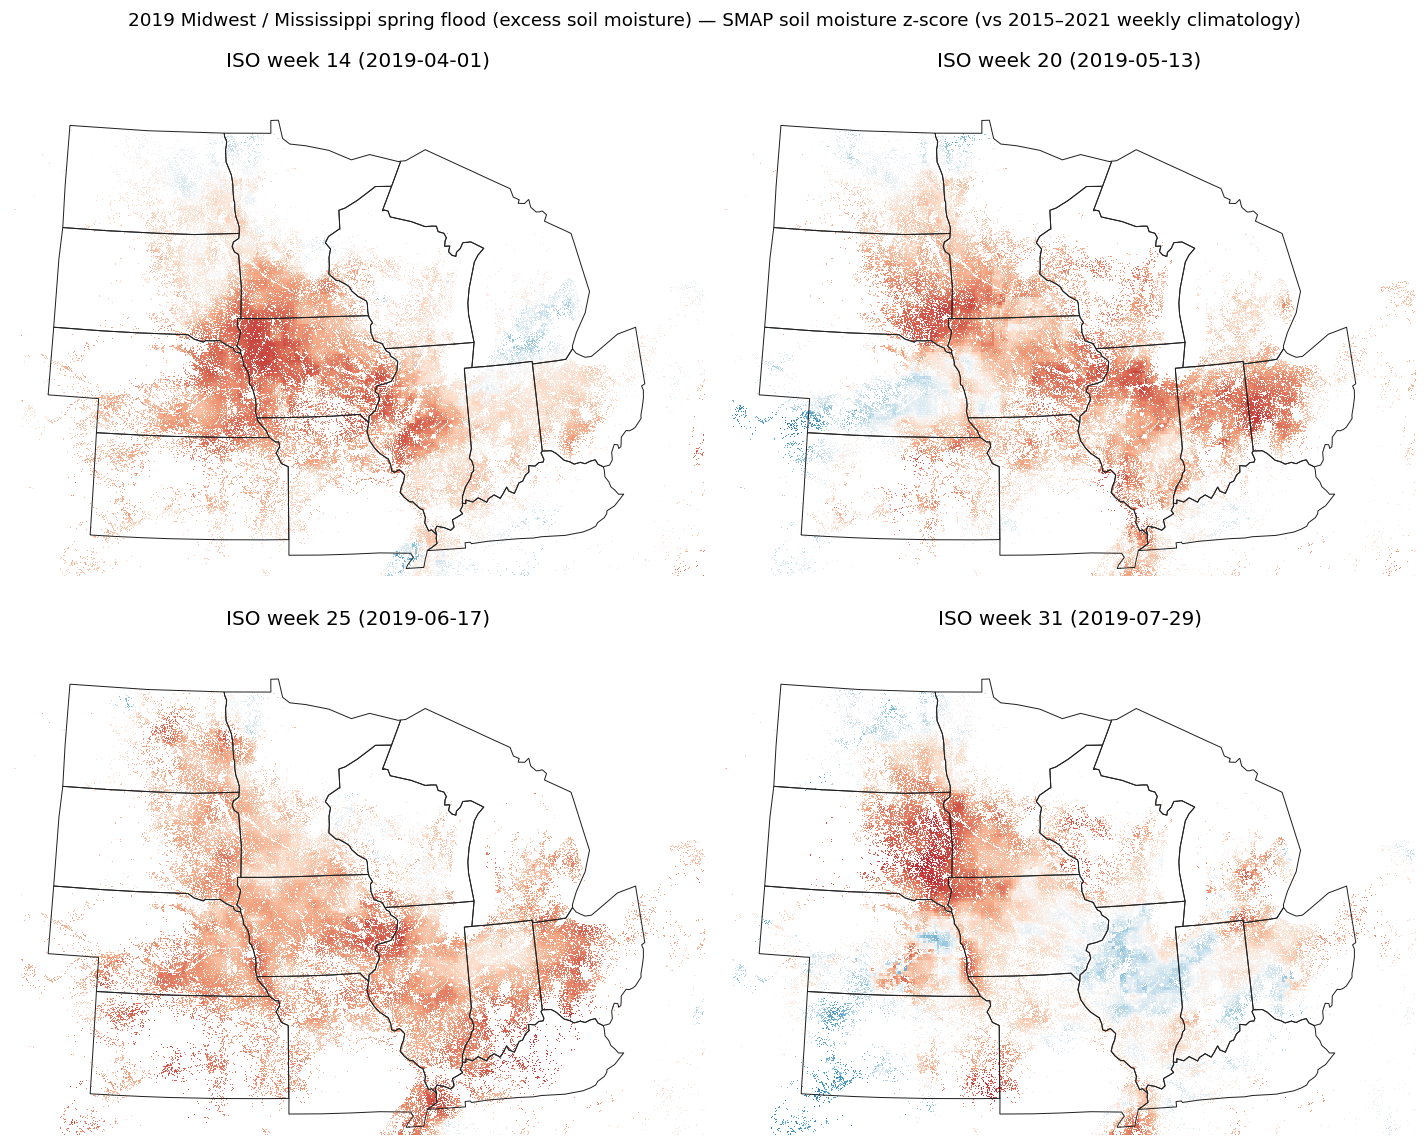

Saved artifacts\figures\task3\task3__midwest_flood_2019__anomaly_map_4panel__20260412.png


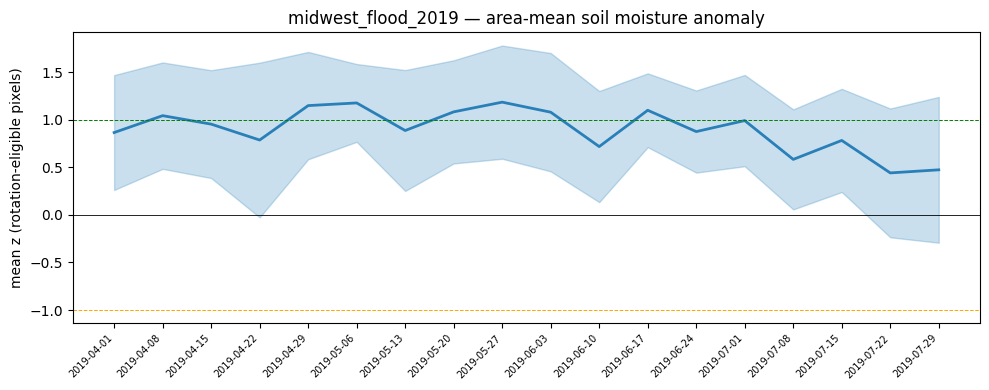

Saved artifacts\figures\task3\task3__midwest_flood_2019__anomaly_timeseries_cropland__20260412.png


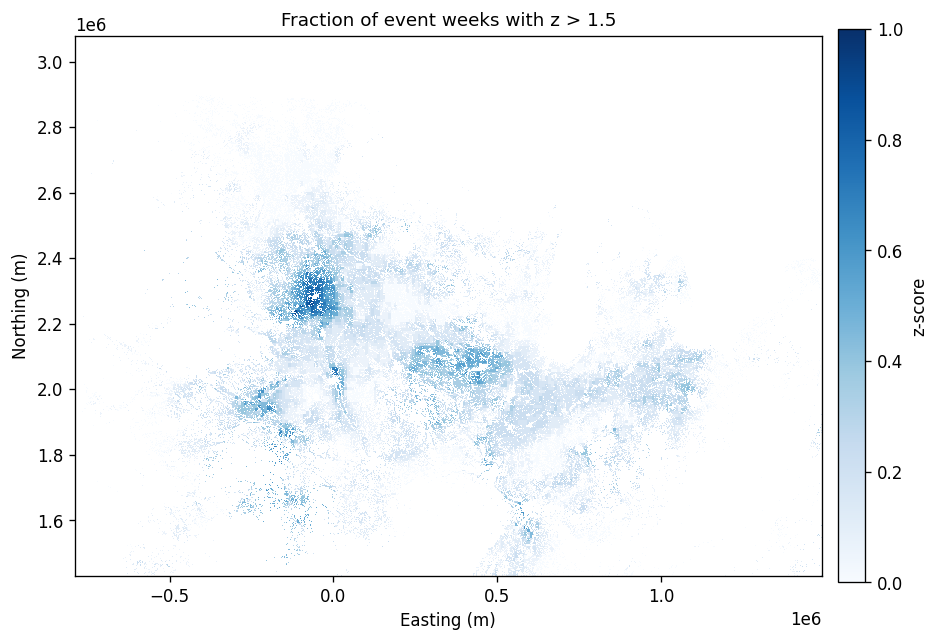

Saved artifacts\figures\task3\task3__midwest_flood_2019__duration_fraction__20260412.png
Wrote artifacts\tables\task3\task3__midwest_flood_2019__anomaly_stats_by_state_crop__20260412.csv


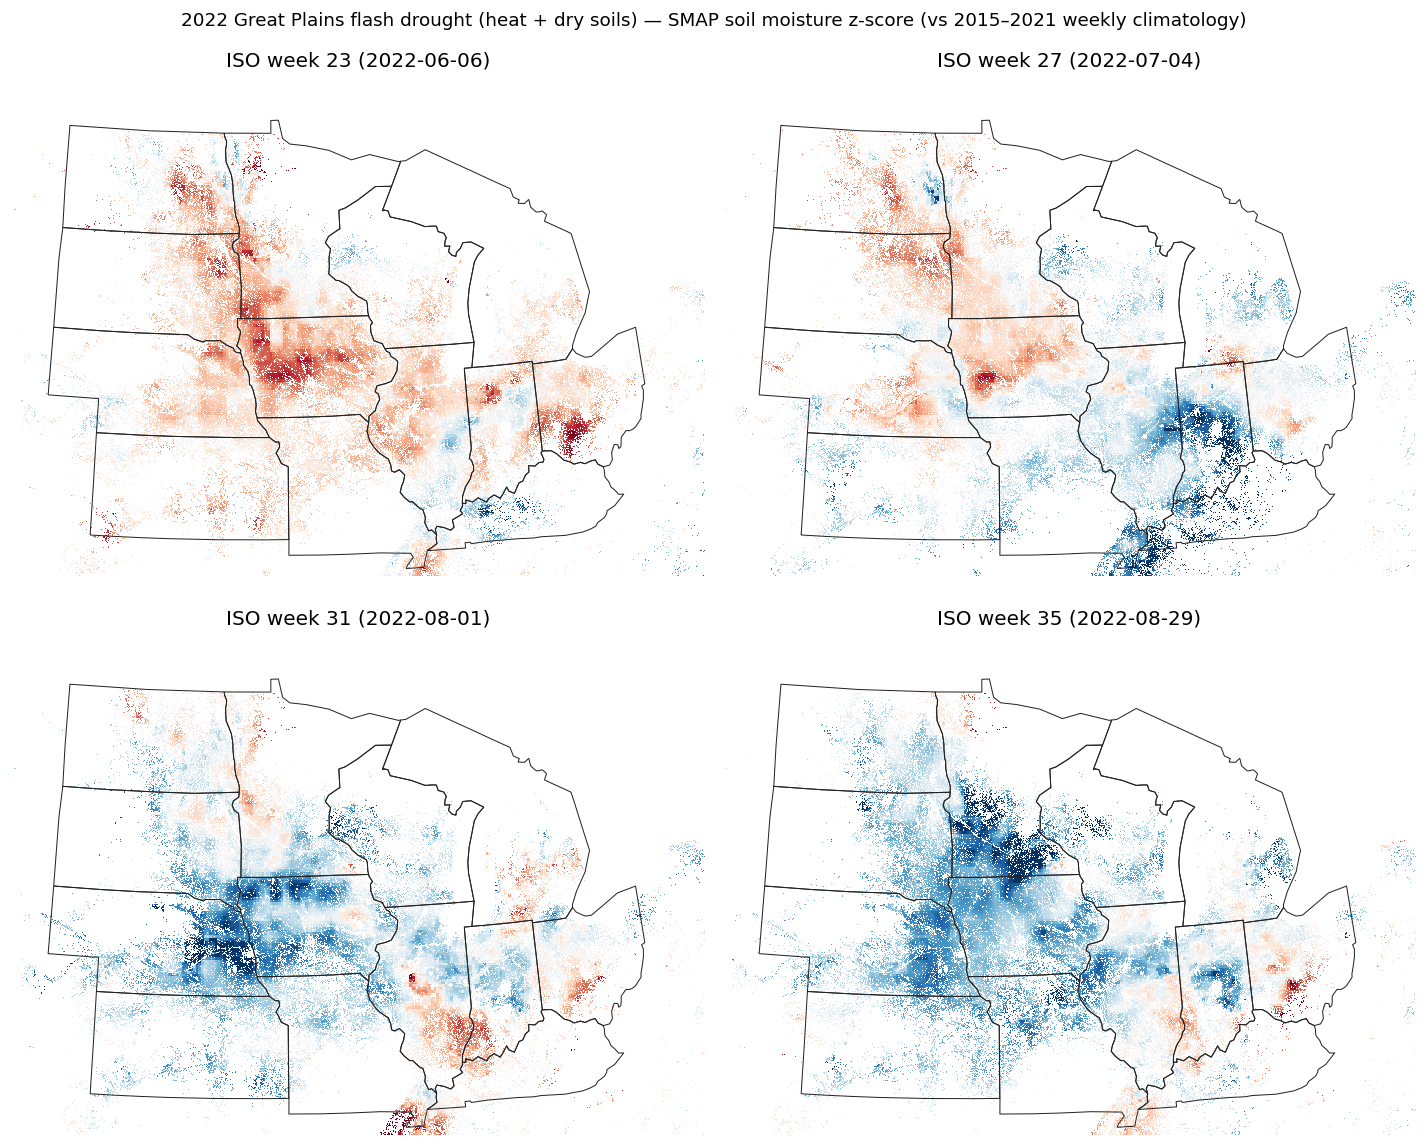

Saved artifacts\figures\task3\task3__plains_drought_2022__anomaly_map_4panel__20260412.png


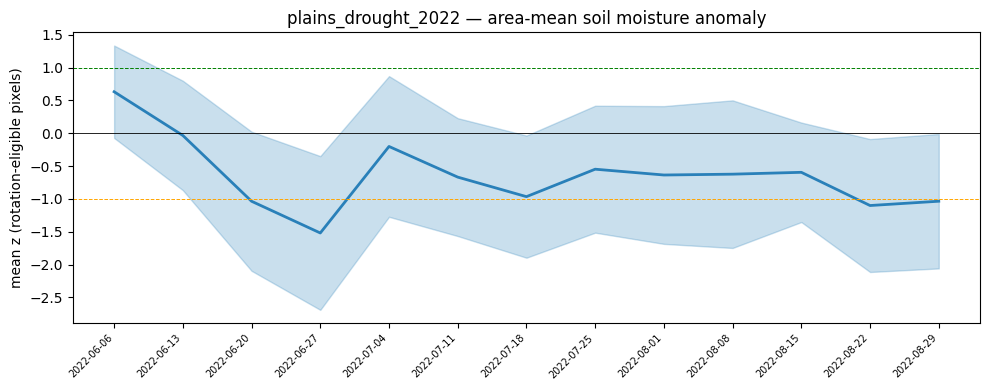

Saved artifacts\figures\task3\task3__plains_drought_2022__anomaly_timeseries_cropland__20260412.png


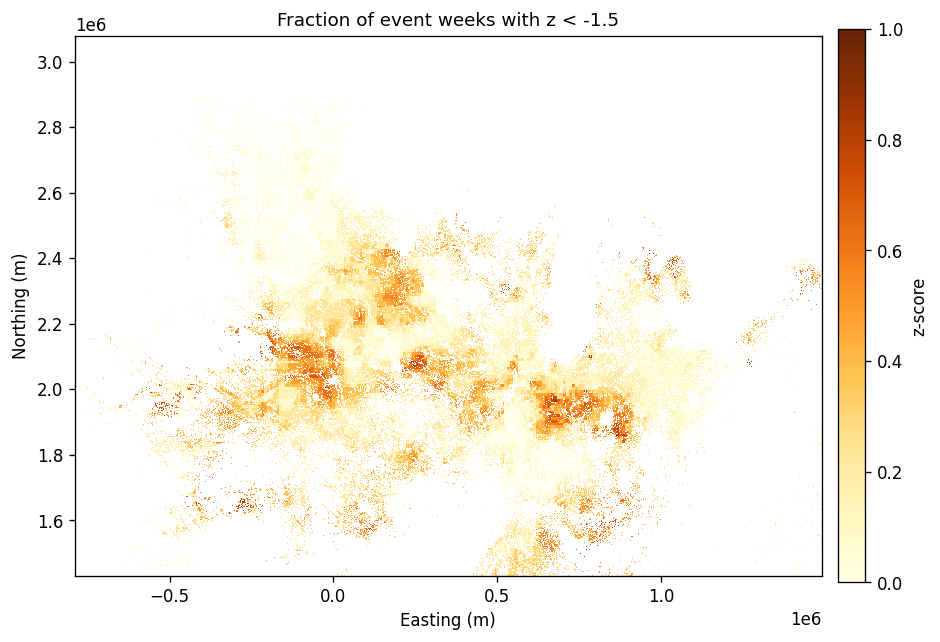

Saved artifacts\figures\task3\task3__plains_drought_2022__duration_fraction__20260412.png
Wrote artifacts\tables\task3\task3__plains_drought_2022__anomaly_stats_by_state_crop__20260412.csv
Wrote artifacts\logs\runs\90168916\run_bundle.json


In [3]:
import json
import sys
import uuid
from datetime import date, datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

_cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in (_cwd, *_cwd.parents) if (p / "requirements.txt").is_file() and (p / "src").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError("Repo root not found")
sys.path.insert(0, str(REPO_ROOT))

from src.io.cdl_parquet import load_cdl_spatial_metadata
from src.modeling.task3_aggregate import attach_state_name, state_crop_anomaly_summary
from src.modeling.task3_smap_anomalies import event_windows_from_cfg
from src.viz.rotation_maps import load_cornbelt_state_boundaries_5070
from src.viz.task3_maps import fill_raster, plot_extent_from_metadata, plot_z_map

with open(REPO_ROOT / "configs" / "task3_soil_moisture.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

events = event_windows_from_cfg(cfg)
meta = load_cdl_spatial_metadata(REPO_ROOT)
h, w = int(meta["height"]), int(meta["width"])
extent = plot_extent_from_metadata(meta)
states = load_cornbelt_state_boundaries_5070(REPO_ROOT)

fig_dir = REPO_ROOT / cfg["output"]["figures_dir"]
tbl_dir = REPO_ROOT / cfg["output"]["tables_dir"]
fig_dir.mkdir(parents=True, exist_ok=True)
tbl_dir.mkdir(parents=True, exist_ok=True)
date_s = date.today().strftime("%Y%m%d")

out_root = REPO_ROOT / cfg["output"]["processed_dir"]
outputs_by_event: dict[str, dict] = {}


def panel_iso_weeks(iso_series: pd.Series) -> list[int]:
    wks = sorted({int(w) for w in iso_series.dropna().unique()})
    n = len(wks)
    if n == 0:
        return []
    if n <= 4:
        return wks
    idx = np.linspace(0, n - 1, num=4, dtype=float)
    pick = sorted({int(round(i)) for i in idx})
    return [wks[i] for i in pick]


def duration_fraction_by_pixel(anom: pd.DataFrame, mode: str, z_thr: float) -> pd.DataFrame:
    z = anom["z_score"].to_numpy()
    if mode == "dry_below":
        flag = z < float(z_thr)
    else:
        flag = z > float(z_thr)
    x = anom.assign(_hit=flag)
    return x.groupby(["iy", "ix"], as_index=False)["_hit"].mean().rename(columns={"_hit": "frac_weeks"})


for ev in events:
    eid = str(ev["id"])
    label = str(ev.get("label", eid))
    mode = str(ev.get("duration_mode", "wet_above"))
    z_thr = float(ev.get("duration_z", 1.5 if mode != "dry_below" else -1.5))

    anom_pq = out_root / f"smap_anomaly_{eid}.parquet"
    if not anom_pq.is_file():
        raise FileNotFoundError(f"Run notebook 02 first: missing {anom_pq}")
    anom = pd.read_parquet(anom_pq)
    anom = attach_state_name(REPO_ROOT, anom)

    targets = panel_iso_weeks(anom["iso_week"])
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=120)
    axes = axes.ravel()
    for ax, tw in zip(axes, targets):
        sub = anom.loc[anom["iso_week"] == tw].drop_duplicates(subset=["iy", "ix"])
        if sub.empty:
            ax.set_axis_off()
            continue
        g = fill_raster(h, w, sub["iy"].to_numpy(), sub["ix"].to_numpy(), sub["z_score"].to_numpy())
        ax.imshow(g, extent=list(extent), origin="upper", interpolation="nearest", cmap="RdBu_r", vmin=-3, vmax=3)
        if states is not None and not states.empty:
            states.boundary.plot(ax=ax, color="#222", linewidth=0.6)
        d0 = sub["date"].iloc[0]
        ax.set_title(f"ISO week {tw} ({d0})")
        ax.set_axis_off()
    fig.suptitle(f"{label} — SMAP soil moisture z-score (vs 2015–2021 weekly climatology)", fontsize=11)
    fig.tight_layout()
    p4 = fig_dir / f"task3__{eid}__anomaly_map_4panel__{date_s}.png"
    fig.savefig(p4, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved", p4.relative_to(REPO_ROOT))

    ts = anom.groupby("date", as_index=False).agg(
        mean_z=("z_score", "mean"), std_z=("z_score", "std"), n=("z_score", "count")
    )
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    x = np.arange(len(ts))
    ax2.plot(x, ts["mean_z"], color="#2980b9", lw=2)
    ax2.fill_between(x, ts["mean_z"] - ts["std_z"], ts["mean_z"] + ts["std_z"], alpha=0.25, color="#2980b9")
    ax2.axhline(0, color="k", lw=0.6)
    ax2.axhline(1, color="g", ls="--", lw=0.7)
    ax2.axhline(-1, color="orange", ls="--", lw=0.7)
    ax2.set_xticks(x)
    ax2.set_xticklabels(ts["date"], rotation=45, ha="right", fontsize=7)
    ax2.set_ylabel("mean z (rotation-eligible pixels)")
    ax2.set_title(f"{eid} — area-mean soil moisture anomaly")
    fig2.tight_layout()
    pts = fig_dir / f"task3__{eid}__anomaly_timeseries_cropland__{date_s}.png"
    fig2.savefig(pts, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved", pts.relative_to(REPO_ROOT))

    cnt = duration_fraction_by_pixel(anom, mode, z_thr)
    g3 = fill_raster(h, w, cnt["iy"].to_numpy(), cnt["ix"].to_numpy(), cnt["frac_weeks"].to_numpy())
    if mode == "dry_below":
        dur_title = f"Fraction of event weeks with z < {z_thr}"
        dur_cmap = "YlOrBr"
    else:
        dur_title = f"Fraction of event weeks with z > {z_thr}"
        dur_cmap = "Blues"
    fig3, ax3 = plot_z_map(g3, extent, title=dur_title, vmin=0, vmax=1, cmap=dur_cmap)
    dur_png = fig_dir / f"task3__{eid}__duration_fraction__{date_s}.png"
    fig3.savefig(dur_png, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved", dur_png.relative_to(REPO_ROOT))

    tab = state_crop_anomaly_summary(anom)
    csv_path = tbl_dir / f"task3__{eid}__anomaly_stats_by_state_crop__{date_s}.csv"
    tab.to_csv(csv_path, index=False)
    print("Wrote", csv_path.relative_to(REPO_ROOT))

    outputs_by_event[eid] = {
        "label": label,
        "duration_mode": mode,
        "duration_z": z_thr,
        "smap_anomaly_parquet": str(anom_pq.relative_to(REPO_ROOT)).replace("\\", "/"),
        "figures_4panel": str(p4.relative_to(REPO_ROOT)).replace("\\", "/"),
        "figures_timeseries": str(pts.relative_to(REPO_ROOT)).replace("\\", "/"),
        "figures_duration": str(dur_png.relative_to(REPO_ROOT)).replace("\\", "/"),
        "table_state_crop": str(csv_path.relative_to(REPO_ROOT)).replace("\\", "/"),
    }

run_id = uuid.uuid4().hex[:8]
run_dir = REPO_ROOT / "artifacts" / "logs" / "runs" / run_id
run_dir.mkdir(parents=True, exist_ok=True)
bundle = {
    "task": "task3_soil_moisture",
    "run_id": run_id,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "config_path": "configs/task3_soil_moisture.yaml",
    "outputs_by_event": outputs_by_event,
}
(run_dir / "run_bundle.json").write_text(json.dumps(bundle, indent=2), encoding="utf-8")
print("Wrote", (run_dir / "run_bundle.json").relative_to(REPO_ROOT))
